# CloudBank Allocations and Spend Reporting Notebook

Compatible with XDMoD Data Analytics Framework v1.0.0

See the [xdmod-notebooks](https://github.com/ubccr/xdmod-notebooks) repository for information on setup, support, contributing, licensing, and referencing.

## Introduction

This notebook uses API access to the production data in XDMoD portal via the [xdmod_data](https://pypi.org/project/xdmod-data) Python package. It uses the XDMoD API to request data, load them into [Pandas](https://pandas.pydata.org/) [DataFrames](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html), and generate plots.

The XDMoD Data Analytics Framework can be run either in an XDMoD-hosted JupyterHub (e.g., by clicking the "JupyterLab" button in ACCESS XDMoD) or locally on your machine (Jupyter Hub or Docker).

## Install, upgrade, and configure

Install or upgrade the packages needed to run this notebook.

In [135]:
import sys
! {sys.executable} -m pip install --upgrade 'xdmod-data[report]>=1.0.0,<2.0.0' python-dotenv tabulate

If running that code caused a new version of Plotly to be installed/upgraded, you may need to refresh your browser window for plots to appear correctly.

### Exceptions

Run the code below to simplify how Python exceptions are displayed in this notebook.

In [1]:
import sys
def exception_handler(exception_type, exception, traceback):
    print("%s: %s" % (exception_type.__name__, exception), file=sys.stderr)
get_ipython()._showtraceback = exception_handler

### Tables

Run the code below to set up for displaying Pandas DataFrames as Markdown tables in this notebook.

In [2]:
from IPython.display import display, Markdown
def display_df_md_table(df):
    return display(Markdown(df.replace('\n', '<br/>', regex=True).to_markdown()))

### Plots

Run the code below to set up the external Plotly package to make plots using a custom XDMoD theme.

In [3]:
import plotly.express as px
import plotly.io as pio
import xdmod_data.themes
pio.templates.default = 'timeseries'

## Authenticate with XDMoD

To run in a Jupyter Lab environment, you must first obtain an API token from the XDMoD portal. Save it to a file that can be accessed by the Jupyter environment (e.g., in the home directory at `~/xdmod-data.env`) with the contents `XDMOD_API_TOKEN=my_token`. This file should be saved with `600` permissions (user read/write only). 

To obtain an API token from the XDMoD portal follow [these instructions](https://github.com/ubccr/xdmod-data#api-token-access).

When run, the code cell below will read your token from `~/xdmod-data.env` into the environment, which will be used later when you start running methods from the API. It will print `True` if it successfully loaded the file.

In [1]:
from dotenv import load_dotenv
from os.path import expanduser
from pathlib import Path

# use XDMoD API token
load_dotenv(Path(expanduser('~/xdmod-data.env')), override=True)

## Initialize the DataWarehouse object

Run the code below to initialize a `DataWarehouse` object that will be used for making the API calls to Production XDMoD.

We assume here that you are running in a local Jupyter Lab environment (not an XDMoD hosted JupyterHub). So, we specify the URL of the XDMoD portal as a string parameter to the `DataWarehouse` constructor (Alternately we could set the `XDMOD_HOST` environment variable).

In [5]:
from xdmod_data.warehouse import DataWarehouse
dw = DataWarehouse('https://xdmod.access-ci.org')

In [6]:
## Verify xdmod_data version
from xdmod_data import __version__
print(__version__)

1.1.0


## Get and plot the CloudBank data

### Variables

Run the code below to set up variables used throughout this notebook.

In [7]:
# Set some variables
plot_duration = '1 year'
plot_type = 'timeseries' # this is the default, anyhow
plot_aggregation = 'month'
plot_top_n = 5

### Plots

Run the code below to fetch data and plot it.

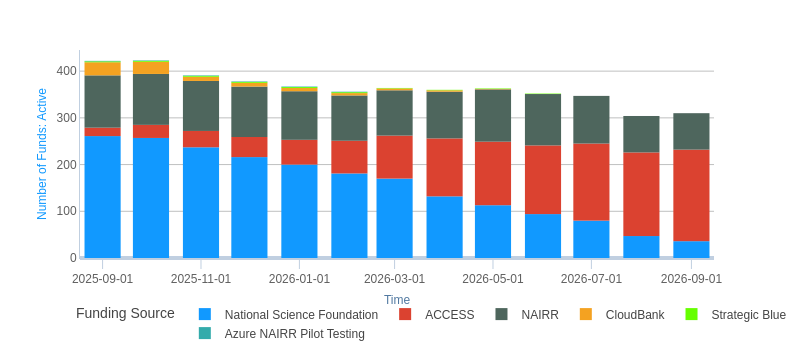

In [8]:
# 1. CloudBank Funds: Number of Active Funds by Funding Source, 1 year
metric_name = 'Number of Funds: Active'
with dw:
    df = dw.get_data(
        duration=plot_duration,
        realm='CloudBankFunds',
        metric=metric_name, #'cb_total_fund_count',
        dimension='cb_funder', # funding source
        filters={},
        dataset_type='timeseries',
        aggregation_unit=plot_aggregation,
    )
plot = px.bar(df, labels={'value': metric_name})
plot.show()

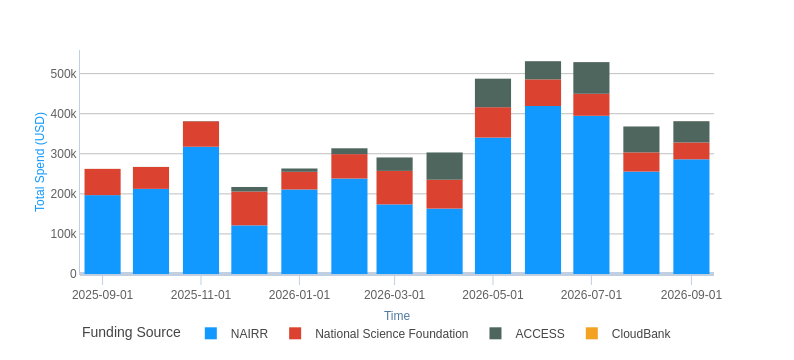

In [9]:
# 2. CloudBank Spend: Total Spend by Funding Source, 1 year
metric_name = 'Total Spend (USD)'
with dw:
    df = dw.get_data(
        duration=plot_duration,
        realm='CloudBankSpend',
        metric=metric_name, 
        dimension='cb_funder', # funding source
        filters={},
        dataset_type='timeseries',
        aggregation_unit=plot_aggregation,
    )
plot = px.bar(df, labels={'value': metric_name})
plot.show()

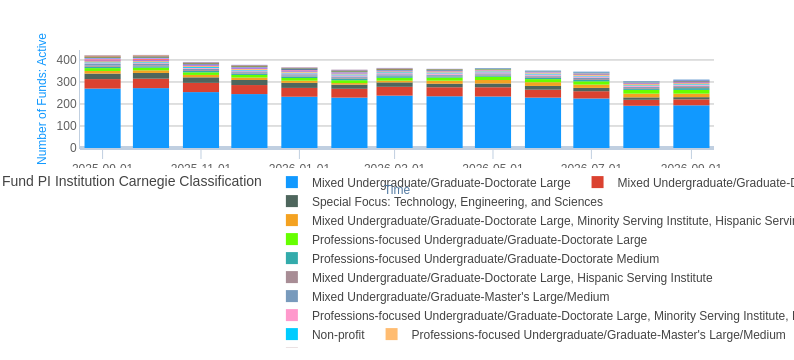

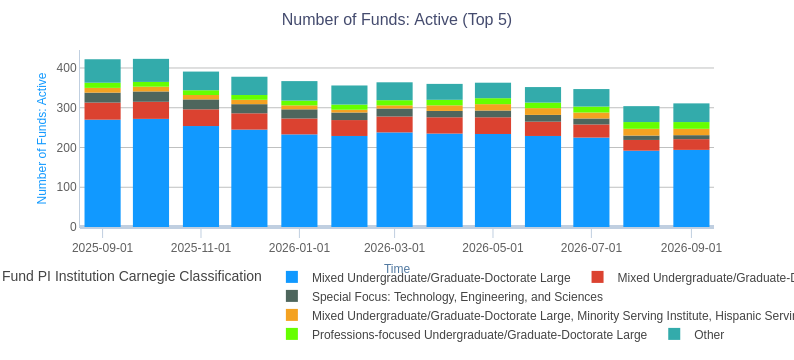

In [10]:
# 3. CloudBank Funds: Allocations by Carnegie Classification, 1 year
# Limit dimensions plotted to top N (plot_top_n)
metric_name = 'Number of Funds: Active'

def build_top_n(df, plot_top_n):
    
    # Pluck off the top N columns from the df:
    top_n = df.iloc[:, :plot_top_n]
    
    # The remainder columns sum into "Other": pick up "bottom": iloc n+1 to end
    bottom = df.iloc[:, plot_top_n:]
    top_n["Other"]=bottom.sum(axis="columns")
    return top_n

with dw:
    df = dw.get_data(
        duration=plot_duration,
        realm='CloudBankFunds',
        metric=metric_name, 
        dimension='cb_pi_institution_carnegie_classification',
        filters={},
        aggregation_unit=plot_aggregation,
    )
    
# full plot of df looks like this:
plot = px.bar(df, labels={'value': metric_name})
plot.show()

# Build the top_n df 
top_n = build_top_n(df, plot_top_n)

# and plot that top N:
plot = px.bar(top_n, labels={'value': metric_name}, 
              title = metric_name + ' (Top ' + str(plot_top_n) + ')')
plot.show() 

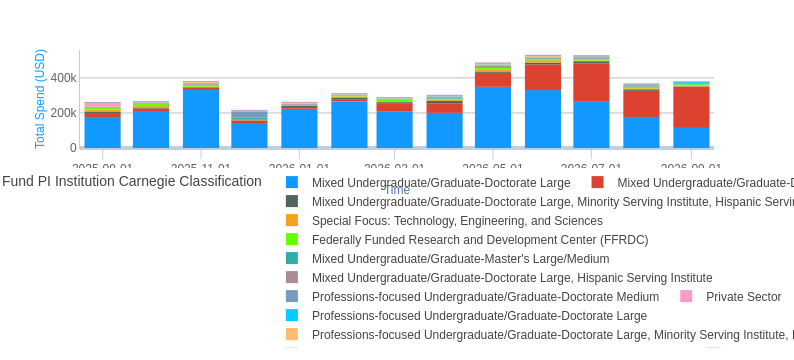

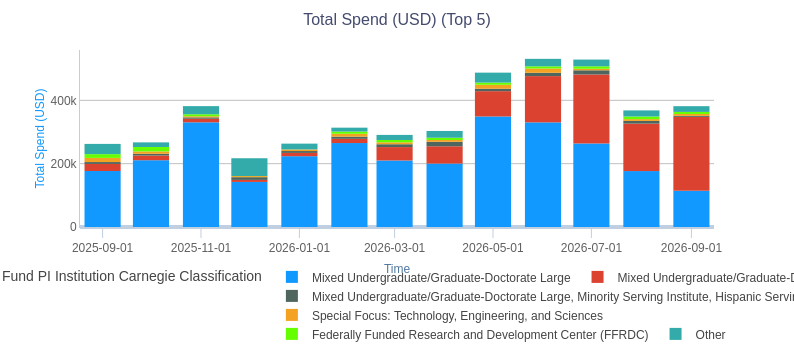

In [11]:
# 4. CloudBank Spend timeseries by Carnegie Classification, 1 year
# limit dimension count to top N
metric_name = 'Total Spend (USD)'

with dw:
    df = dw.get_data(
        duration=plot_duration,
        realm='CloudBankSpend',
        metric=metric_name, 
        dimension='cb_pi_institution_carnegie_classification',
        filters={},
        aggregation_unit=plot_aggregation,
    )
# full plot of df looks like this:
plot = px.bar(df, labels={'value': metric_name})
plot.show()

# Build the top_n df 
top_n = build_top_n(df, plot_top_n)

# and plot that top N:
plot = px.bar(top_n, labels={'value': metric_name}, 
              title = metric_name + ' (Top ' + str(plot_top_n) + ')')
plot.show()  

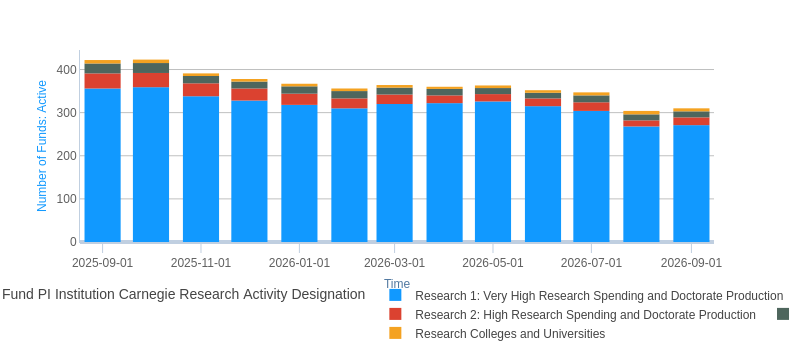

In [12]:
# 5. CloudBank Funds: Allocations by Carnegie Research Designation, 1 year
metric_name = 'Number of Funds: Active'

with dw:
    df = dw.get_data(
        duration=plot_duration,
        realm='CloudBankFunds',
        metric=metric_name, 
        dimension='cb_pi_institution_carnegie_research_designation',
        filters={},
        aggregation_unit=plot_aggregation,
    )
plot = px.bar(df, labels={'value': metric_name})
plot.show()

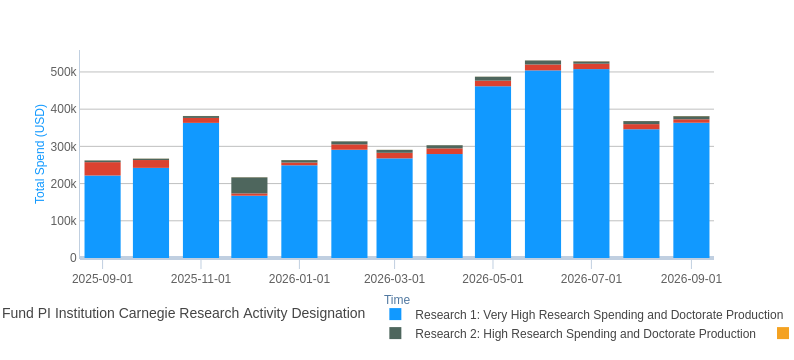

In [13]:
# 6. CloudBank Spend:  Spend by Carnegie Research Designation, 1 year
metric_name = 'Total Spend (USD)'

with dw:
    df = dw.get_data(
        duration=plot_duration,
        realm='CloudBankSpend',
        metric=metric_name, 
        dimension='cb_pi_institution_carnegie_research_designation',
        filters={},
        dataset_type='timeseries',
        aggregation_unit=plot_aggregation,
    )
plot = px.bar(df, labels={'value': metric_name})
plot.show()

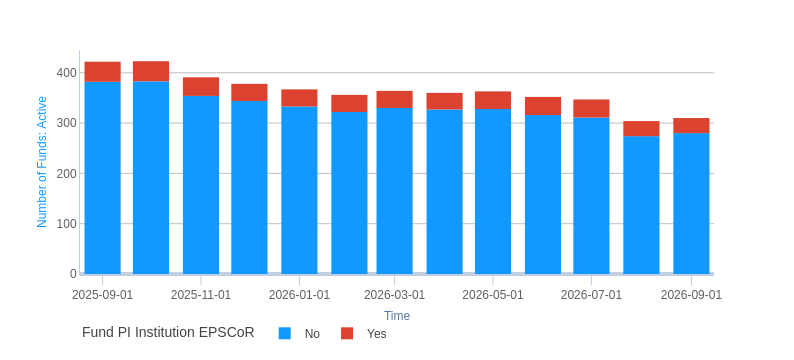

In [14]:
# 7. CloudBank Funds: Allocations by EPSCoR, 1 year
metric_name = 'Number of Funds: Active'

with dw:
    df = dw.get_data(
        duration=plot_duration,
        realm='CloudBankFunds',
        metric=metric_name, 
        dimension='cb_pi_institution_epscor',
        filters={},
        dataset_type='timeseries',
        aggregation_unit=plot_aggregation,
    )
plot = px.bar(df, labels={'value': metric_name})
plot.show()

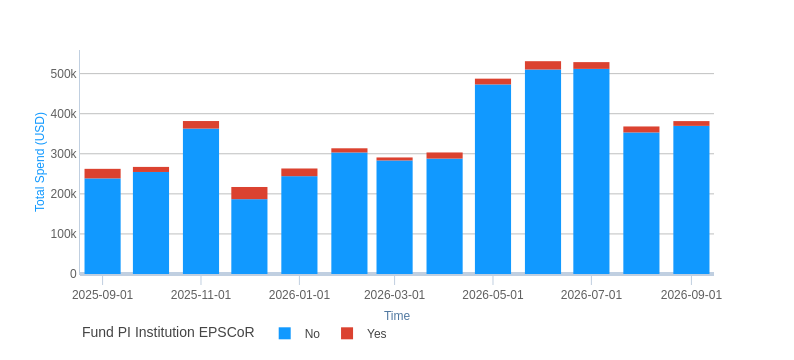

Fund PI Institution EPSCoR,No,Yes
Time,,
2025-09-01,238603.426272,23816.72293
2025-10-01,254606.886873,12649.38561
2025-11-01,362868.525653,18853.273025
2025-12-01,186733.437794,30389.479868
2026-01-01,244146.219387,19159.563875
2026-02-01,303267.194727,10439.37818
2026-03-01,283384.027915,7472.790986
2026-04-01,288004.538894,15289.286417
2026-05-01,473095.069946,14377.36425


In [15]:
# 8. CloudBank Spend:  Spend by EPSCoR, 1 year
metric_name = 'Total Spend (USD)'

with dw:
    df = dw.get_data(
        duration=plot_duration,
        realm='CloudBankSpend',
        metric=metric_name, 
        dimension='cb_pi_institution_epscor',
        filters={},
        dataset_type='timeseries',
        aggregation_unit=plot_aggregation,
    )
plot = px.bar(df, labels={'value': metric_name})
plot.show()
df

In [16]:
## Here we run into some trouble with the PI_institution_State dimension

In [17]:
# 9. CloudBank Funds: Allocations by PI institution state, 1 year
# AttributeError: 'NoneType' object has no attribute 'group'
metric_name = 'Number of Funds: Active'
with dw:
    df = dw.get_data(
        duration='1 year',
        realm='CloudBankFunds',
        metric=metric_name, 
        dimension='cb_pi_institution_state' #, # ?? Fund PI Institution State', #
        #filters={},
        #dataset_type='timeseries',
        #aggregation_unit='Month',
    )
plot = px.bar(df, labels={'value': metric_name})
plot.show()

AttributeError: 'NoneType' object has no attribute 'group'


In [18]:
# here's our dimension. Is it the id with the blank label that causes trouble here?
with dw:
    filter_values = dw.get_filter_values('CloudBankFunds', 'cb_pi_institution_state')
display_df_md_table(filter_values)

|   id | label                |
|-----:|:---------------------|
|   46 |                      |
|    3 | Alabama              |
|   32 | Alaska               |
|    2 | Arizona              |
|   33 | Arkansas             |
|    9 | California           |
|   12 | Colorado             |
|   34 | Connecticut          |
|   35 | Delaware             |
|   18 | District of Columbia |
|   16 | Florida              |
|   15 | Georgia              |
|   36 | Hawaii               |
|    6 | Idaho                |
|    1 | Illinois             |
|   19 | Indiana              |
|   20 | Iowa                 |
|   37 | Kansas               |
|   38 | Kentucky             |
|   22 | Louisiana            |
|   47 | Maine                |
|   21 | Maryland             |
|    7 | Massachusetts        |
|   24 | Michigan             |
|   39 | Minnesota            |
|   26 | Mississippi          |
|   40 | Missouri             |
|   41 | Nebraska             |
|   13 | New Hampshire        |
|   27 | New Jersey           |
|   28 | New Mexico           |
|    5 | New York             |
|   14 | North Carolina       |
|   29 | Ohio                 |
|   43 | Oklahoma             |
|   49 | Ontario              |
|   30 | Oregon               |
|   10 | Pennsylvania         |
|   53 | Puerto Rico          |
|    8 | Rhode Island         |
|   11 | South Carolina       |
|   44 | South Dakota         |
|   31 | Tennessee            |
|    4 | Texas                |
|   45 | Utah                 |
|   17 | Virginia             |
|   25 | Washington           |
|   23 | Wisconsin            |

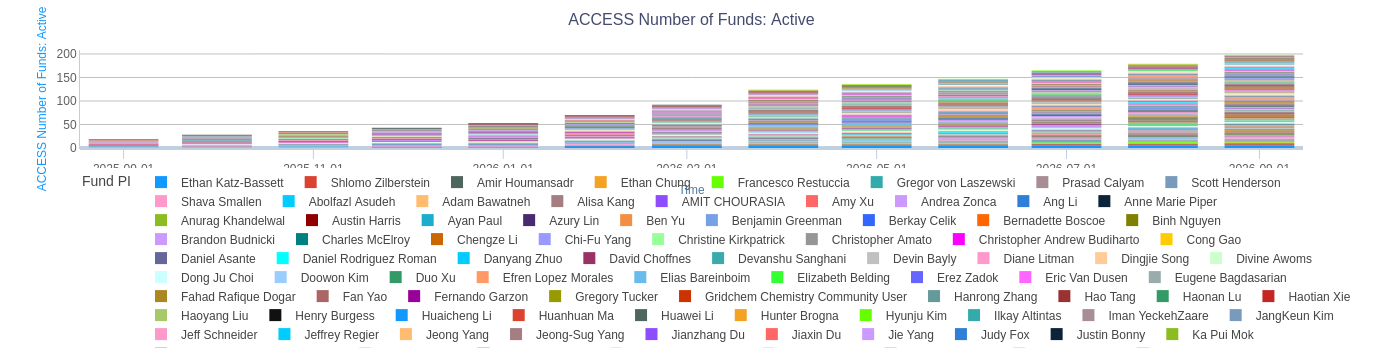

In [19]:
# 9a. CloudBank Funds: ACCESS Allocations by PI, 1 year
# filter by single funding source to avoid duplicates

metric_name = 'Number of Funds: Active'
funding_source_filter = 'ACCESS'

with dw:
    df = dw.get_data(
        duration=plot_duration,
        realm='CloudBankFunds',
        metric=metric_name, 
        dimension='cb_pi', 
        dataset_type='timeseries',
        aggregation_unit=plot_aggregation,
        filters={'Funding Source': 
            funding_source_filter}
    )

plot = px.bar(df, labels={'value': funding_source_filter + ' ' + metric_name},
              title = funding_source_filter + ' ' + metric_name)
plot.show()

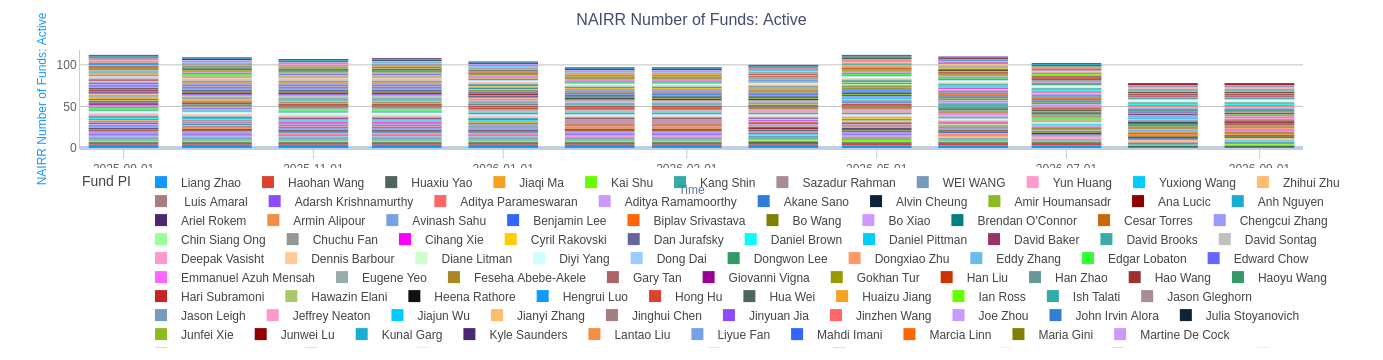

In [20]:
# 9b. CloudBank Funds: NAIRR Allocations by PI, 1 year
# filter by single funding source to avoid duplicates

metric_name = 'Number of Funds: Active'
funding_source_filter = 'NAIRR'

with dw:
    df = dw.get_data(
        duration=plot_duration,
        realm='CloudBankFunds',
        metric=metric_name, 
        dimension='cb_pi', 
        dataset_type='timeseries',
        aggregation_unit=plot_aggregation,
        filters={'Funding Source': 
            funding_source_filter},        
    )
   
plot = px.bar(df, labels={'value': funding_source_filter + ' ' + metric_name},
              title = funding_source_filter + ' ' + metric_name)
plot.show()

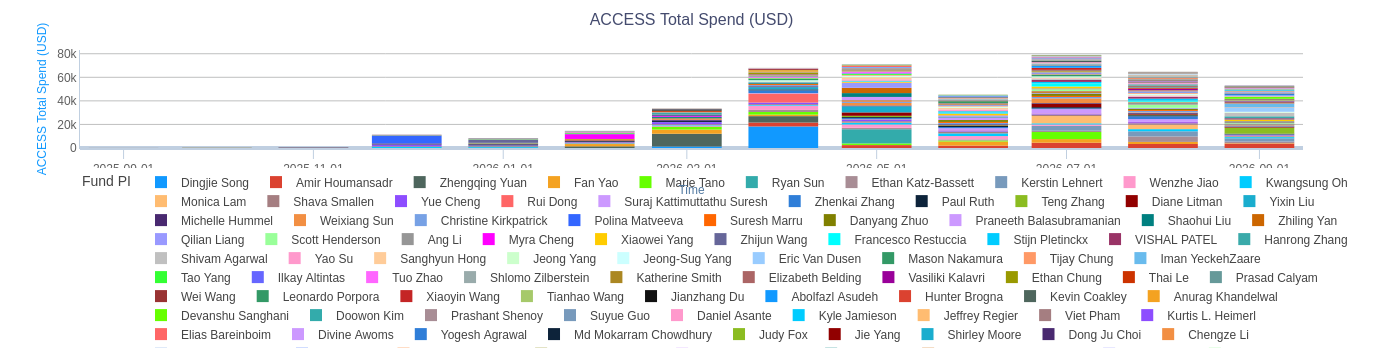

In [21]:
# 10a. CloudBank Spend:  ACCESS Spend by PI institution, 1 year
# **Note that we care more about this than about the Funds one
#
# Use ACCESS Funding Source filter to prevent duplicate PI names
#
metric_name = 'Total Spend (USD)'
funding_source_filter = 'ACCESS'

with dw:
    df = dw.get_data(
        duration=plot_duration,
        realm='CloudBankSpend',
        metric=metric_name, 
        dimension='cb_pi', 
        filters={'Funding Source': 
            funding_source_filter
            },
        dataset_type='timeseries',
        aggregation_unit=plot_aggregation,
    )
   
plot = px.bar(df, labels={'value': funding_source_filter + ' ' + metric_name},
              title = funding_source_filter + ' ' + metric_name)
plot.show()


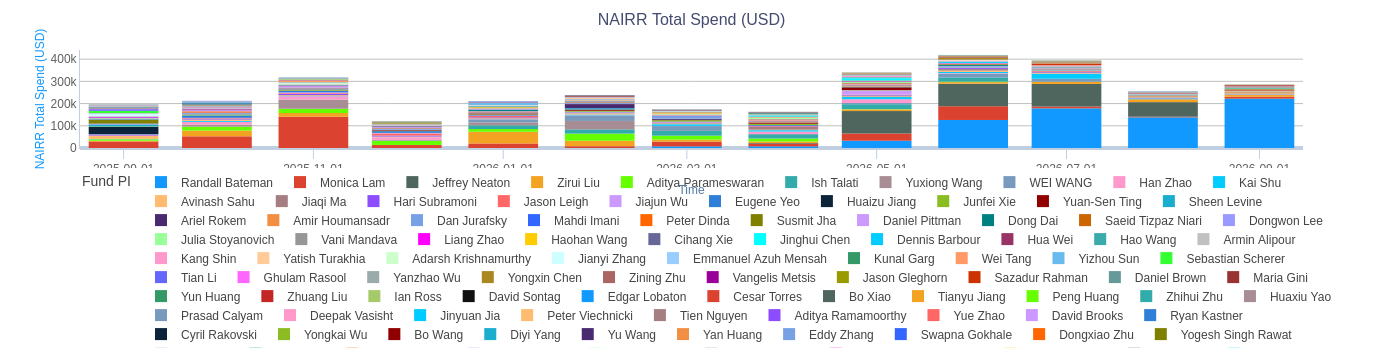

In [22]:
# 10b. CloudBank Spend:  NAIRR Spend by PI institution, 1 year
# **Note that we care more about this than about the Funds one
#
# Use NAIRR Funding Source filter to prevent duplicates on PI name
metric_name = 'Total Spend (USD)'
funding_source_filter = 'NAIRR'

with dw:
    df = dw.get_data(
        duration=plot_duration,
        realm='CloudBankSpend',
        metric=metric_name, 
        dimension='cb_pi', 
        filters={'Funding Source': 
            funding_source_filter
            },
        dataset_type='timeseries',
        aggregation_unit=plot_aggregation,
    )
plot = px.bar(df, labels={'value': funding_source_filter + ' ' + metric_name},
              title = funding_source_filter + ' ' + metric_name)
plot.show()

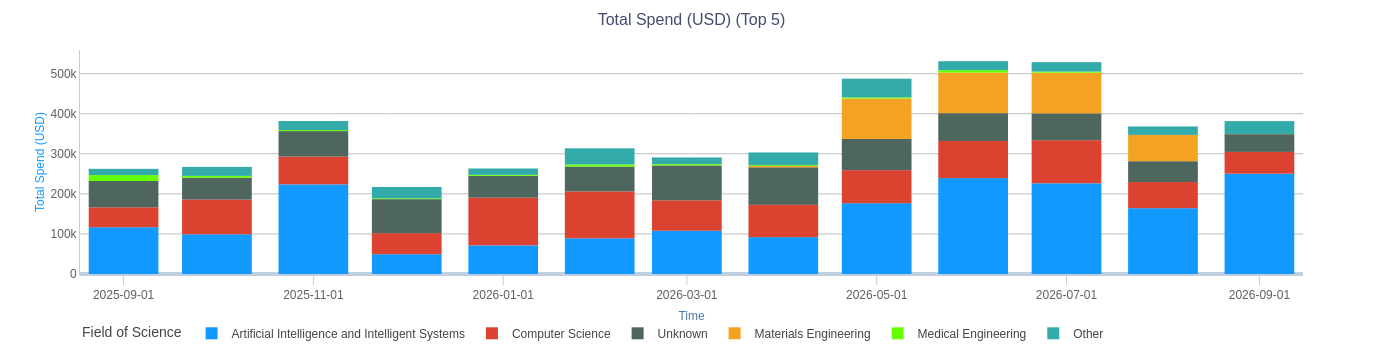

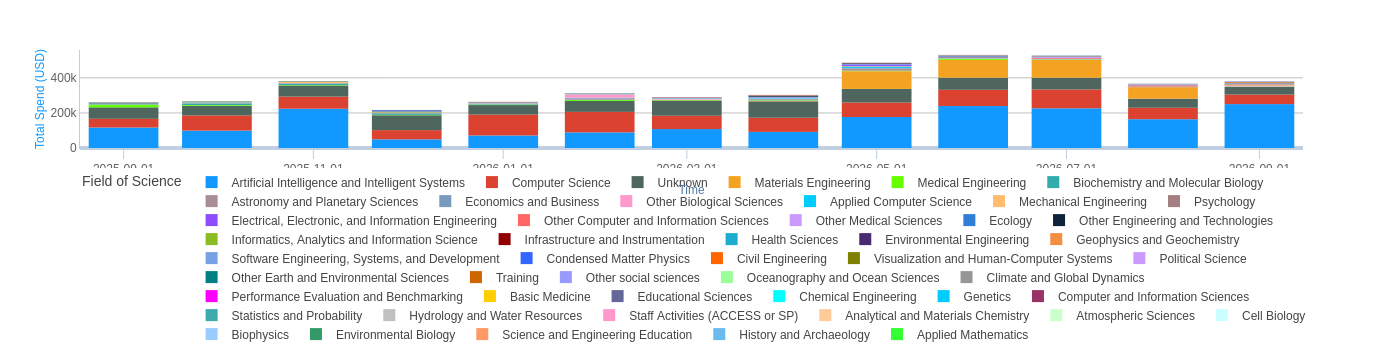

In [23]:
# CloudBank Spend:  Spend by Field of Science, 1 year
metric_name = 'Total Spend (USD)'
with dw:
    df = dw.get_data(
        duration=plot_duration,
        realm='CloudBankSpend',
        metric=metric_name, 
        dimension='cb_field_of_science',
        filters={},
        dataset_type='timeseries',
        aggregation_unit=plot_aggregation,
    )
# Build the top_n df 
top_n = build_top_n(df, plot_top_n)

plot = px.bar(top_n, labels={'value': metric_name}, 
              title = metric_name + ' (Top ' + str(plot_top_n) + ')')
plot.show()

# full df
plot = px.bar(df, labels={'value': metric_name})
plot.show()

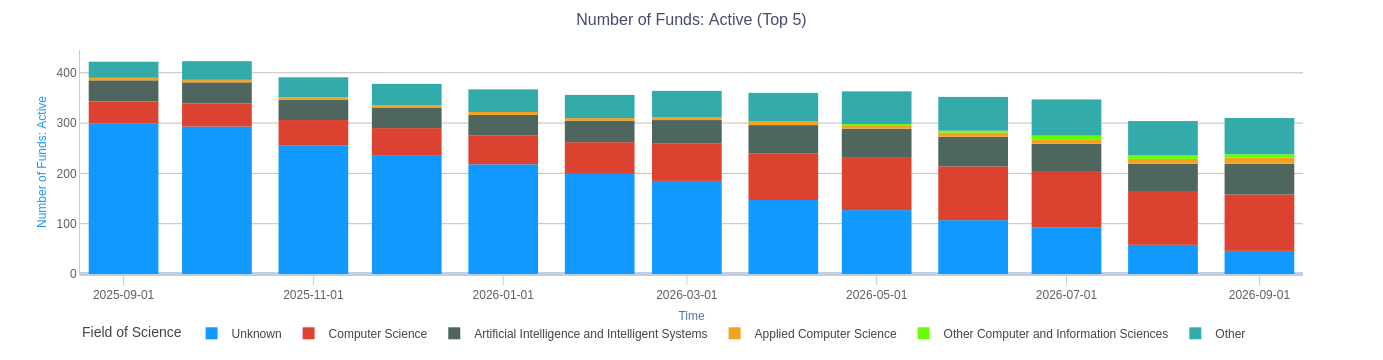

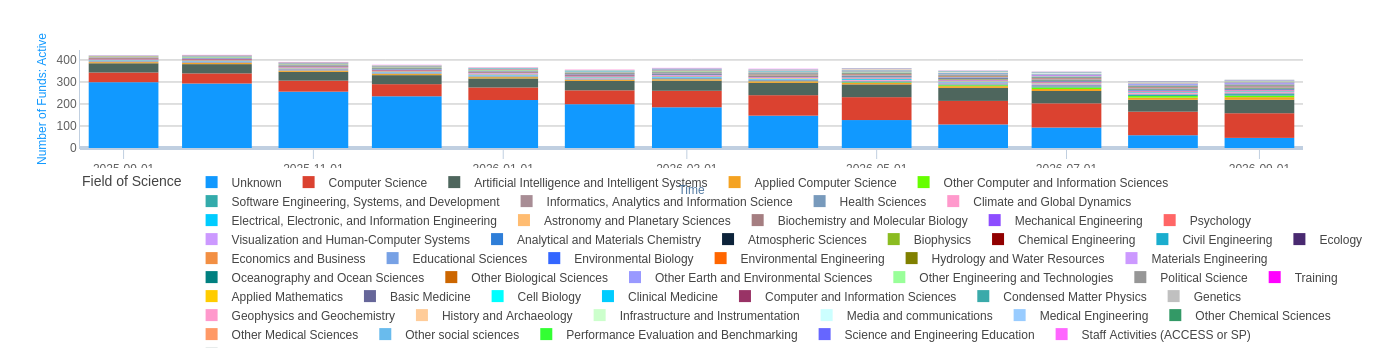

In [24]:
# CloudBank Funds:  Allocations by Field of Science, 1 year
metric_name = 'Number of Funds: Active'
with dw:
    df = dw.get_data(
        duration=plot_duration,
        realm='CloudBankFunds',
        metric=metric_name, 
        dimension='cb_field_of_science',
        filters={},
        dataset_type='timeseries',
        aggregation_unit=plot_aggregation,
    )

# Build the top_n df 
top_n = build_top_n(df, plot_top_n)
plot = px.bar(top_n, labels={'value': metric_name}, 
              title = metric_name + ' (Top ' + str(plot_top_n) + ')')
plot.show()

# the full plot
plot = px.bar(df, labels={'value': metric_name})
plot.show()

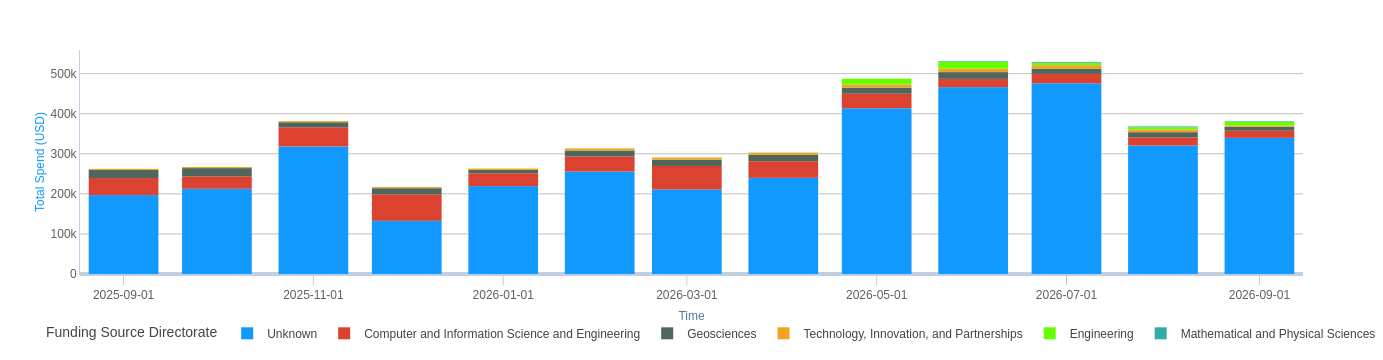

In [25]:
# CloudBank Spend:  Spend by NSF Directorate, 1 year
metric_name = 'Total Spend (USD)'

with dw:
    df = dw.get_data(
        duration=plot_duration,
        realm='CloudBankSpend',
        metric=metric_name, 
        dimension='cb_nsf_directorate',
        filters={},
        dataset_type='timeseries',
        aggregation_unit=plot_aggregation,
    )
plot = px.bar(df, labels={'value': metric_name})
plot.show()

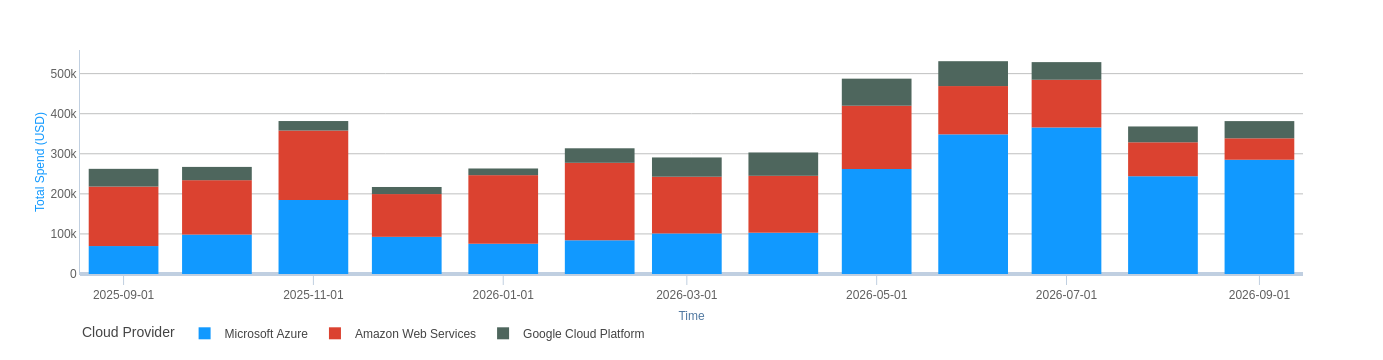

In [26]:
# CloudBank Spend:  Spend by Cloud Vendor, 1 year
metric_name = 'Total Spend (USD)'

with dw:
    df = dw.get_data(
        duration=plot_duration,
        realm='CloudBankSpend',
        metric=metric_name, 
        dimension='cb_cloud_provider',
        filters={},
        dataset_type='timeseries',
        aggregation_unit=plot_aggregation,
    )
plot = px.bar(df, labels={'value': metric_name})
plot.show()

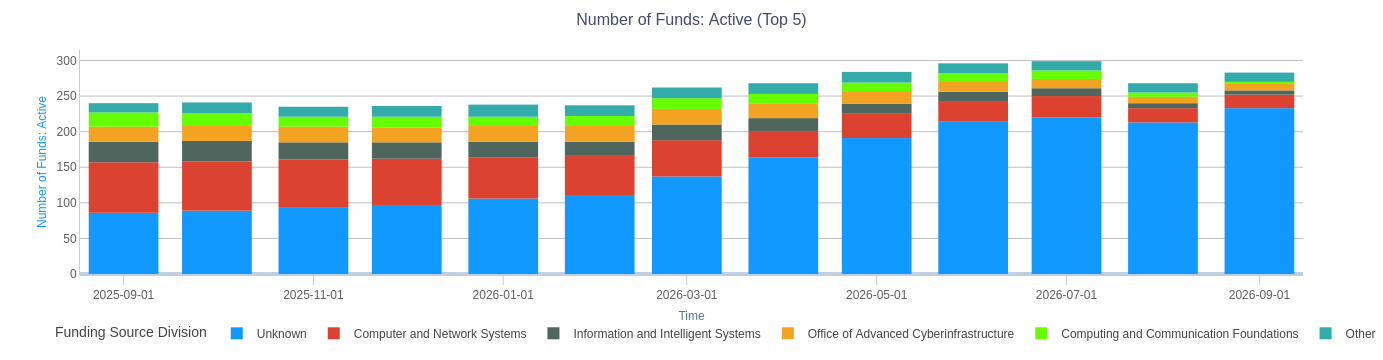

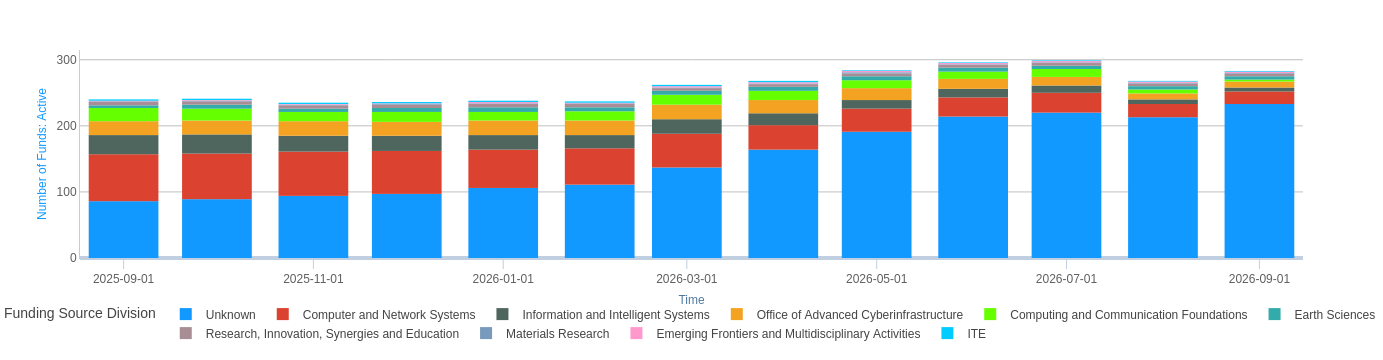

In [27]:
# CloudBank Funds:  Allocations by Division, 1 year
metric_name = 'Number of Funds: Active'

with dw:
    df = dw.get_data(
        duration=plot_duration,
        realm='CloudBankSpend',
        metric=metric_name, 
        dimension='cb_nsf_division',
        filters={},
        dataset_type='timeseries',
        aggregation_unit=plot_aggregation,
    )

top_n = build_top_n(df, plot_top_n)
plot = px.bar(top_n, 
              labels={'value': metric_name}, 
              title = metric_name + ' (Top ' + str(plot_top_n) + ')')
plot.show()

# full df
plot = px.bar(df, labels={'value': metric_name})
plot.show()

In [28]:
# Just trying things...
# CloudBank Funds:  Allocations by CloudBank Location, 1 year
# TODO: we have a blank label in cb_location, handle this
metric_name = 'Number of Funds: Active'

with dw:
    df = dw.get_data(
        duration=plot_duration,
        realm='CloudBankSpend',
        metric=metric_name, 
        dimension='cb_location',
        filters={},
        dataset_type='timeseries',
        aggregation_unit=plot_aggregation,
    )

top_n = build_top_n(df, plot_top_n)
plot = px.bar(top_n, 
              labels={'value': metric_name}, 
              title = metric_name + ' (Top ' + str(plot_top_n) + ')')
plot.show()

# full df
#plot = px.bar(df, labels={'value': metric_name})
#plot.show()

AttributeError: 'NoneType' object has no attribute 'group'


In [29]:
# cb_location: blank label for id=1
with dw:
    filter_values = dw.get_filter_values('CloudBankSpend', 'cb_location') 
display_df_md_table(filter_values)

|   id | label                   |
|-----:|:------------------------|
|    1 |                         |
|    2 | AE North                |
|    3 | af-south-1              |
|    4 | af-south-1-los-1        |
|    5 | africa-south1           |
|    6 | All                     |
|    7 | allregions              |
|    8 | AP Southeast            |
|    9 | ap-east-1               |
|   10 | ap-northeast-1          |
|   11 | ap-northeast-1-tpe-1    |
|   12 | ap-northeast-2          |
|   13 | ap-northeast-3          |
|   14 | ap-south-1              |
|   15 | ap-south-1-del-1        |
|   16 | ap-south-2              |
|   17 | ap-southeast-1          |
|   18 | ap-southeast-2          |
|   19 | ap-southeast-3          |
|   20 | ap-southeast-4          |
|   21 | ap-southeast-5          |
|   22 | Asia                    |
|   23 | asia-east1              |
|   24 | asia-east2              |
|   25 | asia-northeast1         |
|   26 | asia-northeast2         |
|   27 | asia-northeast3         |
|   28 | asia-south1             |
|   29 | asia-south2             |
|   30 | asia-southeast1         |
|   31 | asia-southeast2         |
|   32 | AU East                 |
|   33 | Australia Central       |
|   34 | Australia East          |
|   35 | Australia Southeast     |
|   36 | australia-southeast1    |
|   37 | australia-southeast2    |
|   38 | BR South                |
|   39 | Brazil South            |
|   40 | CA Central              |
|   41 | CA East                 |
|   42 | ca-central-1            |
|   43 | ca-west-1               |
|   44 | Canada Central          |
|   45 | Canada East             |
|   46 | Central India           |
|   47 | Central US              |
|   48 | DE West Central         |
|   49 | East Asia               |
|   50 | East US                 |
|   51 | East US 2               |
|   52 | EU North                |
|   53 | EU West                 |
|   54 | eu-central-1            |
|   55 | eu-central-1-ham-1      |
|   56 | eu-central-1-waw-1      |
|   57 | eu-central-2            |
|   58 | eu-north-1              |
|   59 | eu-south-1              |
|   60 | eu-south-2              |
|   61 | eu-west-1               |
|   62 | eu-west-2               |
|   63 | eu-west-3               |
|   64 | Europe                  |
|   65 | europe-central2         |
|   66 | europe-north1           |
|   67 | europe-southwest1       |
|   68 | europe-west1            |
|   69 | europe-west10           |
|   70 | europe-west12           |
|   71 | europe-west2            |
|   72 | europe-west3            |
|   73 | europe-west4            |
|   74 | europe-west6            |
|   75 | europe-west8            |
|   76 | europe-west9            |
|   77 | FR Central              |
|   78 | France Central          |
|   79 | Germany West Central    |
|   80 | global                  |
|   81 | il-central-1            |
|   82 | Intercontinental        |
|   83 | israelcentral           |
|   84 | IT North                |
|   85 | italynorth              |
|   86 | JA East                 |
|   87 | JA West                 |
|   88 | Japan East              |
|   89 | Japan West              |
|   90 | Korea Central           |
|   91 | Korea South             |
|   92 | me-central-1            |
|   93 | me-central1             |
|   94 | me-central2             |
|   95 | me-south-1              |
|   96 | me-west1                |
|   97 | mexicocentral           |
|   98 | multi-region            |
|   99 | mx-central-1            |
|  100 | newzealandnorth         |
|  101 | North America           |
|  102 | North Central US        |
|  103 | North Europe            |
|  104 | northamerica-northeast1 |
|  105 | northamerica-northeast2 |
|  106 | northamerica-south1     |
|  107 | norwayeast              |
|  108 | PL Central              |
|  109 | polandcentral           |
|  110 | qatarcentral            |
|  111 | sa-east-1               |
|  112 | SE Central              |
|  113 | South Africa North      |
|  114 | South Central US        |
|  115 | South East Asia         |
|  116 | South India             |
|  117 | southamerica-east1      |
|  118 | southamerica-west1      |
|  119 | spaincentral            |
|  120 | swedencentral           |
|  121 | Switzerland North       |
|  122 | true                    |
|  123 | UAE North               |
|  124 | UK South                |
|  125 | UK West                 |
|  126 | Unassigned              |
|  127 | US Central              |
|  128 | US East                 |
|  129 | US East 2               |
|  130 | US North Central        |
|  131 | US South Central        |
|  132 | US West                 |
|  133 | US West 2               |
|  134 | US West 3               |
|  135 | US West Central         |
|  136 | us-central1             |
|  137 | us-central2             |
|  138 | us-east-1               |
|  139 | us-east-1-atl-1         |
|  140 | us-east-1-bos-1         |
|  141 | us-east-1-bue-1         |
|  142 | us-east-1-chi-1         |
|  143 | us-east-1-dfw-1         |
|  144 | us-east-1-iah-1         |
|  145 | us-east-1-lim-1         |
|  146 | us-east-1-mci-1         |
|  147 | us-east-1-mia-1         |
|  148 | us-east-1-msp-1         |
|  149 | us-east-1-nyc-1         |
|  150 | us-east-1-phl-1         |
|  151 | us-east-1-qro-1         |
|  152 | us-east-1-scl-1         |
|  153 | us-east-1-wl1           |
|  154 | us-east-1-wl1-nyc1      |
|  155 | us-east-2               |
|  156 | us-east1                |
|  157 | us-east2                |
|  158 | us-east4                |
|  159 | us-east5                |
|  160 | us-east7                |
|  161 | us-south1               |
|  162 | us-west-1               |
|  163 | us-west-2               |
|  164 | us-west-2-den-1         |
|  165 | us-west-2-hnl-1         |
|  166 | us-west-2-las-1         |
|  167 | us-west-2-lax-1         |
|  168 | us-west-2-pdx-1         |
|  169 | us-west-2-phx-1         |
|  170 | us-west-2-sea-1         |
|  171 | us-west1                |
|  172 | us-west2                |
|  173 | us-west3                |
|  174 | us-west4                |
|  175 | West Central US         |
|  176 | West Europe             |
|  177 | West India              |
|  178 | West US                 |
|  179 | West US 2               |
|  180 | West US 3               |
|  181 | Zone 1                  |
|  286 | austriaeast             |
|  287 | belgiumcentral          |
|  288 | chilecentral            |
|  289 | indonesiacentral        |
|  290 | malaysiawest            |
|  348 | us-central3             |
|  352 | europe-west11           |
|  353 | europe-west7            |
|  354 | us-west5                |
|  355 | us-west8                |
|  386 | europe-north2           |
|  445 | ID Central              |
|  462 | NO East                 |
|  501 | Oceania                 |
|  555 | denmarkeast             |
|  556 | indiasouthcentral       |
|  569 | us-east10               |
|  576 | ap east                 |
|  577 | at east                 |
|  578 | australiaeast           |
|  579 | be central              |
|  580 | centralus               |
|  581 | ch north                |
|  582 | cl central              |
|  583 | eastus                  |
|  584 | eastus2                 |
|  585 | es central              |
|  586 | il central              |
|  587 | in central              |
|  588 | kr central              |
|  589 | mx central              |
|  590 | my west                 |
|  591 | No Region: Custom       |
|  592 | No Region: Google Cloud |
|  593 | westus3                 |
|  594 | za north                |
|  617 | asia-southeast3         |

In [30]:
# TODO: Data issue? This one works in XDMoD itself but throws the dreaded "AttributeError: 'NoneType' object has no attribute 'group'" here
# CloudBank spend:  Spend by Cloud Service, 1 year
metric_name = 'Total Spend (USD)'
with dw:
    df = dw.get_data(
        duration='1 year',
        realm='CloudBankSpend',
        metric=metric_name, 
        dimension='cb_service',
        filters={},
        dataset_type='timeseries',
        aggregation_unit='month',
    )
#plot = px.line(df, labels={'value': metric_name})
#plot.show()

AttributeError: 'NoneType' object has no attribute 'group'


In [31]:
# It appears that id=1 has a blank label for CloudBankSpend cb_service
with dw:
    filter_values = dw.get_filter_values('CloudBankSpend', 'cb_service')
display_df_md_table(filter_values)

|   id | label                                                             |
|-----:|:------------------------------------------------------------------|
|    1 |                                                                   |
|    2 | Advanced Data Security                                            |
|    3 | AlloyDB                                                           |
|    4 | Amazon API Gateway                                                |
|    5 | Amazon AppStream                                                  |
|    6 | Amazon Athena                                                     |
|    7 | Amazon Bedrock                                                    |
|    8 | Amazon Braket                                                     |
|    9 | Amazon CloudFront                                                 |
|   10 | Amazon Cognito                                                    |
|   11 | Amazon Comprehend                                                 |
|   12 | Amazon DataZone                                                   |
|   13 | Amazon DevOps Guru                                                |
|   14 | Amazon DocumentDB (with MongoDB compatibility)                    |
|   15 | Amazon DynamoDB                                                   |
|   16 | Amazon EC2 Container Registry (ECR)                               |
|   17 | Amazon Elastic Compute Cloud                                      |
|   18 | Amazon Elastic Container Registry Public                          |
|   19 | Amazon Elastic Container Service                                  |
|   20 | Amazon Elastic Container Service for Kubernetes                   |
|   21 | Amazon Elastic File System                                        |
|   22 | Amazon Elastic MapReduce                                          |
|   23 | Amazon ElastiCache                                                |
|   24 | Amazon FSx                                                        |
|   25 | Amazon GameLift                                                   |
|   26 | Amazon GuardDuty                                                  |
|   27 | Amazon HealthLake                                                 |
|   28 | Amazon Kinesis                                                    |
|   29 | Amazon Kinesis Analytics                                          |
|   30 | Amazon Kinesis Firehose                                           |
|   31 | Amazon Lex                                                        |
|   32 | Amazon Lightsail                                                  |
|   33 | Amazon Linux 2 with GUI Mate Desktop VNC / RDP                    |
|   34 | Amazon Managed Blockchain                                         |
|   35 | Amazon Managed Grafana                                            |
|   36 | Amazon Managed Streaming for Apache Kafka                         |
|   37 | Amazon MQ                                                         |
|   38 | Amazon Neptune                                                    |
|   39 | Amazon OpenSearch Service                                         |
|   40 | Amazon Pinpoint                                                   |
|   41 | Amazon Polly                                                      |
|   42 | Amazon QuickSight                                                 |
|   43 | Amazon Redshift                                                   |
|   44 | Amazon Registrar                                                  |
|   45 | Amazon Rekognition                                                |
|   46 | Amazon Relational Database Service                                |
|   47 | Amazon Route 53                                                   |
|   48 | Amazon SageMaker                                                  |
|   49 | Amazon Simple Email Service                                       |
|   50 | Amazon Simple Notification Service                                |
|   51 | Amazon Simple Queue Service                                       |
|   52 | Amazon Simple Storage Service                                     |
|   53 | Amazon Textract                                                   |
|   54 | Amazon Timestream                                                 |
|   55 | Amazon Transcribe                                                 |
|   56 | Amazon Virtual Private Cloud                                      |
|   57 | Amazon WorkSpaces                                                 |
|   58 | AmazonCloudWatch                                                  |
|   59 | AmazonWorkMail                                                    |
|   60 | Apache Kafka® & Apache Flink® on Confluent Cloud™ - Pay As You Go |
|   61 | API Management                                                    |
|   62 | App Engine                                                        |
|   63 | Artifact Registry                                                 |
|   64 | AWS Amplify                                                       |
|   65 | AWS App Runner                                                    |
|   66 | AWS AppSync                                                       |
|   67 | AWS Backup                                                        |
|   68 | AWS CloudTrail                                                    |
|   69 | AWS CodeArtifact                                                  |
|   70 | AWS CodeCommit                                                    |
|   71 | AWS CodePipeline                                                  |
|   72 | AWS Compute Optimizer                                             |
|   73 | AWS Config                                                        |
|   74 | AWS Cost Explorer                                                 |
|   75 | AWS Data Transfer                                                 |
|   76 | AWS DataSync                                                      |
|   77 | AWS DeepRacer                                                     |
|   78 | AWS Direct Connect                                                |
|   79 | AWS Directory Service                                             |
|   80 | AWS End User Messaging                                            |
|   81 | AWS Fault Injection Simulator                                     |
|   82 | AWS Global Accelerator                                            |
|   83 | AWS Glue                                                          |
|   84 | AWS Key Management Service                                        |
|   85 | AWS Lambda                                                        |
|   86 | AWS Parallel Computing Service                                    |
|   87 | AWS Secrets Manager                                               |
|   88 | AWS Security Hub                                                  |
|   89 | AWS Service Catalog                                               |
|   90 | AWS Step Functions                                                |
|   91 | AWS Storage Gateway                                               |
|   92 | AWS Support (Business)                                            |
|   93 | AWS Support (Developer)                                           |
|   94 | AWS Systems Manager                                               |
|   95 | AWS WAF                                                           |
|   96 | AWS X-Ray                                                         |
|   97 | Azure App Service                                                 |
|   98 | Azure Applied AI Services                                         |
|   99 | Azure Bastion                                                     |
|  100 | Azure Cognitive Search                                            |
|  101 | Azure Container Apps                                              |
|  102 | Azure Cosmos DB                                                   |
|  103 | Azure Data Explorer                                               |
|  104 | Azure Data Factory v2                                             |
|  105 | Azure Database for MySQL                                          |
|  106 | Azure Database for PostgreSQL                                     |
|  107 | Azure Databricks                                                  |
|  108 | Azure DNS                                                         |
|  109 | Azure Kubernetes Service                                          |
|  110 | Azure Machine Learning                                            |
|  111 | Azure Monitor                                                     |
|  112 | Azure NetApp Files                                                |
|  113 | Backup                                                            |
|  114 | Backup for GKE                                                    |
|  115 | Bandwidth                                                         |
|  116 | BigQuery                                                          |
|  117 | BigQuery Reservation API                                          |
|  118 | ChatGPT Web                                                       |
|  119 | Claude (Amazon Bedrock Edition)                                   |
|  120 | Claude 3 Haiku                                                    |
|  121 | Claude 3 Haiku (Amazon Bedrock Edition)                           |
|  122 | Claude 3 Opus (Amazon Bedrock Edition)                            |
|  123 | Claude 3 Sonnet (Amazon Bedrock Edition)                          |
|  124 | Claude 3.5 Haiku                                                  |
|  125 | Claude 3.5 Haiku (Amazon Bedrock Edition)                         |
|  126 | Claude 3.5 Sonnet (Amazon Bedrock Edition)                        |
|  127 | Claude 3.5 Sonnet v2                                              |
|  128 | Claude 3.5 Sonnet v2 (Amazon Bedrock Edition)                     |
|  129 | Claude 3.7 Sonnet                                                 |
|  130 | Claude 3.7 Sonnet (Amazon Bedrock Edition)                        |
|  131 | Claude 3.7 Sonnet (Preview)                                       |
|  132 | Claude Opus 4 (Amazon Bedrock Edition)                            |
|  133 | Claude Opus 4.1                                                   |
|  134 | Claude Opus 4.1 (Amazon Bedrock Edition)                          |
|  135 | Claude Sonnet 4                                                   |
|  136 | Claude Sonnet 4 (Amazon Bedrock Edition)                          |
|  137 | Claude Sonnet 4.5                                                 |
|  138 | Claude Sonnet 4.5 (Amazon Bedrock Edition)                        |
|  139 | Cloud Build                                                       |
|  140 | Cloud Dataflow                                                    |
|  141 | Cloud DNS                                                         |
|  142 | Cloud Filestore                                                   |
|  143 | Cloud Functions                                                   |
|  144 | Cloud IDE for Python using Jupyter & Visual Studio Code           |
|  145 | Cloud Key Management Service (KMS)                                |
|  146 | Cloud Logging                                                     |
|  147 | Cloud Memorystore for Redis                                       |
|  148 | Cloud Monitoring                                                  |
|  149 | Cloud Run                                                         |
|  150 | Cloud Run Functions                                               |
|  151 | Cloud Scheduler                                                   |
|  152 | Cloud Spanner                                                     |
|  153 | Cloud SQL                                                         |
|  154 | Cloud Storage                                                     |
|  155 | Cloud TPU                                                         |
|  156 | Cloud Vision API                                                  |
|  157 | Cloud Workstations                                                |
|  158 | CloudWatch Events                                                 |
|  159 | CodeBuild                                                         |
|  160 | Cognitive Services                                                |
|  161 | Cohere Command R+ (Amazon Bedrock Edition)                        |
|  162 | Cohere Embed Model - English (Amazon Bedrock Edition)             |
|  163 | Comprehend Medical                                                |
|  164 | Compute Engine                                                    |
|  165 | Confidential Computing                                            |
|  166 | Container Instances                                               |
|  167 | Container Registry                                                |
|  168 | Container Registry Vulnerability Scanning                         |
|  169 | Deep Learning AMI (Amazon Linux 2) Version 60.0 support by Bansir |
|  170 | Deep Learning AMI GPU PyTorch 2.0.1 Ubuntu 20.04                  |
|  171 | Directions API                                                    |
|  172 | Distance Matrix API                                               |
|  173 | DynamoDB Accelerator (DAX)                                        |
|  174 | EKS Optimized 1.21.2 with DPDK 20.11.2                            |
|  175 | Elastic Cloud (managed Elasticsearch Service)                     |
|  176 | Elastic Load Balancing                                            |
|  177 | EXAScaler Cloud                                                   |
|  178 | Fleets                                                            |
|  179 | Geocoding API                                                     |
|  180 | Google Maps Platform - Routes                                     |
|  181 | Jamba 1.5 Large (Amazon Bedrock Edition)                          |
|  182 | Key Vault                                                         |
|  183 | Kubernetes Engine                                                 |
|  184 | Leap™ Quantum Cloud Service                                       |
|  185 | Load Balancer                                                     |
|  186 | Log Analytics                                                     |
|  187 | Logic Apps                                                        |
|  188 | Managed Service for Apache Kafka                                  |
|  189 | Maps API                                                          |
|  190 | Meta Llama 2 Chat 13B (Amazon Bedrock Edition)                    |
|  191 | Meta Llama 2 Chat 70B (Amazon Bedrock Edition)                    |
|  192 | Microsoft Defender for Cloud                                      |
|  193 | NAT Gateway                                                       |
|  194 | Network Watcher                                                   |
|  195 | Networking                                                        |
|  196 | Notebooks                                                         |
|  197 | Places API                                                        |
|  198 | Quantum Computing                                                 |
|  199 | Redis Cache                                                       |
|  200 | Rocky Linux 8 Latest with support by ProComputers                 |
|  201 | Rocky Linux 8 with LVM with support by ProComputers               |
|  202 | SDXL V1.0 (Amazon Bedrock Edition)                                |
|  203 | Secret Manager                                                    |
|  204 | SQBM+ for AWS Business Standard Plan                              |
|  205 | SQBM+ for AWS Learn & Development Plan                            |
|  206 | SQL Database                                                      |
|  207 | Storage                                                           |
|  208 | Support                                                           |
|  209 | Translate                                                         |
|  210 | Ubuntu 16 (Ubuntu 16.04 LTS) with Support by Supported Images     |
|  211 | Ubuntu 20.04 LTS (Focal Fossa) with support by ProComputers       |
|  212 | Unassigned                                                        |
|  213 | Vertex AI                                                         |
|  214 | Vertex AI Search                                                  |
|  215 | Virtual Machines                                                  |
|  216 | Virtual Machines Licenses                                         |
|  217 | Virtual Network                                                   |
|  218 | Vivado ML 2021.2 Developer AMI                                    |
|  219 | Vivado ML 2022.2 Developer AMI                                    |
|  220 | VPN Gateway                                                       |
|  285 | Foundry Models                                                    |
|  286 | Foundry Tools                                                     |
|  290 | Claude Opus 4.5 (Amazon Bedrock Edition)                          |
|  315 | Claude Haiku 4.5                                                  |
|  320 | AWS Business Support+                                             |
|  324 | RHEL 8.10 Minimal (rhel8) with support by ProComputers            |
|  329 | Claude Haiku 4.5 (Amazon Bedrock Edition)                         |
|  333 | Claude Opus 4.5                                                   |
|  347 | Amazon Bedrock AgentCore                                          |
|  358 | Luma Ray2 (Amazon Bedrock Edition)                                |
|  361 | Claude Opus 4.6                                                   |
|  366 | Mistral Small 3.1 (25.03)                                         |
|  372 | Cloud Pub/Sub                                                     |
|  384 | Claude Opus 4.6 (Amazon Bedrock Edition)                          |
|  388 | Claude Sonnet 4.6 (Amazon Bedrock Edition)                        |
|  391 | Ubuntu 20.04 LTS (Focal Fossa) | Support by ProComputers          |
|  402 | Claude Sonnet 4.6                                                 |
|  418 | MS Bing Services                                                  |
|  445 | Claude Opus 4                                                     |
|  446 | Claude Opus 4.7                                                   |
|  449 | Claude Opus 4.7 (Amazon Bedrock Edition)                          |
|  457 | SaaS                                                              |
|  461 | Ubuntu 26.04 LTS (Resolute Raccoon) | Support by ProComputers     |
|  467 | Azure Applications                                                |
|  481 | SignalR                                                           |
|  504 | Claude Opus 4.8                                                   |
|  525 | Claude Opus 4.8 (Amazon Bedrock Edition)                          |
|  535 | GitHub                                                            |
|  544 | Claude Fable 5                                                    |
|  547 | Claude Fable 5 (Amazon Bedrock Edition)                           |
|  548 | Claude Sonnet 5 (Amazon Bedrock Edition)                          |
|  555 | Email                                                             |
|  558 | Cloud Text-to-Speech API                                          |
|  559 | Virtual Machine Licenses                                          |
|  564 | Claude Sonnet 5                                                   |
|  565 | Kiro                                                              |
|  574 | Vivado ML 2024.2 Developer AMI                                    |
|  578 | Claude Opus 5 (Amazon Bedrock Edition)                            |
|  579 | OpenAI GPT-5.4 (Amazon Bedrock Edition)                           |
|  580 | OpenAI GPT-5.5 (Amazon Bedrock Edition)                           |
|  585 | Claude Opus 5                                                     |
|  622 | AWSMarketplace                                                    |
|  623 | BigQuery Storage API                                              |
|  624 | Gemini API                                                        |
|  625 | VM Manager                                                        |
|  629 | AmazonMQ                                                          |
|  637 | AmazonKnowledgeBase                                               |
|  640 | Azure Front Door Service                                          |
|  647 | AWSCostExplorer                                                   |

In [32]:
#display(filter_values)
#filter_values[1:]

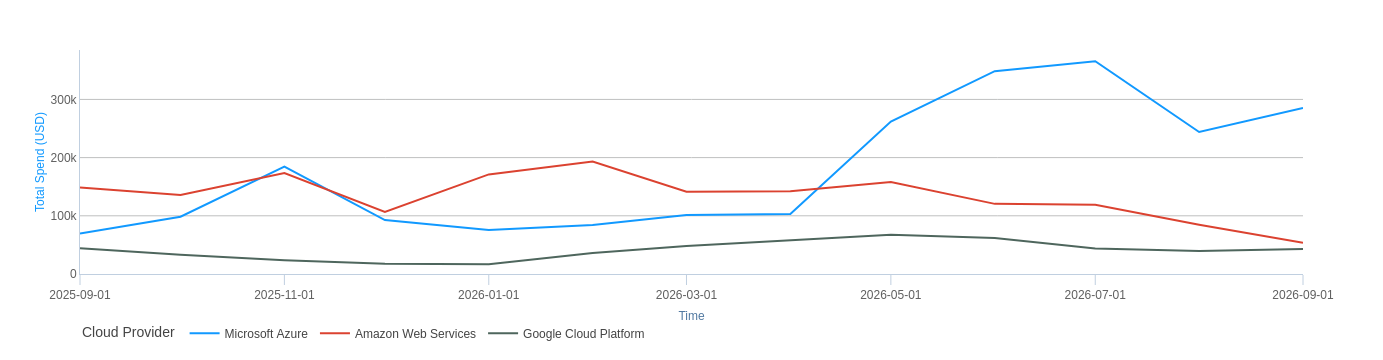

In [33]:
# Just exploring
# CloudBank spend:  Spend by Cloud Provider, 1 year
metric_name = 'Total Spend (USD)'
with dw:
    df = dw.get_data(
        duration=plot_duration,
        realm='CloudBankSpend',
        metric=metric_name, 
        dimension='cb_cloud_provider',
        filters={},
        dataset_type='timeseries',
        aggregation_unit=plot_aggregation,
    )
plot = px.line(df, labels={'value': metric_name})
plot.show()


# Document Version History
| Version | Date  | Notes |
| ------- | ----- | ----- |
| 1 | 2026-09-10 | Initial version |


---
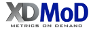
XDMoD Data Analytics Framework 1.1.0 

In [34]:
# This cell is used to create the footer of this notebook.
from xdmod_data.report import footer
footer({
    'history': [
        ['1', '2026-09-10', 'Initial version'],
    ],
})